In [20]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
import numpy as np

In [21]:
# Load the CIFAR-10 dataset.
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

In [22]:
# Print the shapes of the loaded data
# .shape attribute gives the dimensions of the numpy arrays
print("--- Dataset Shapes ---")
print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Testing images shape:", test_images.shape)
print("Testing labels shape:", test_labels.shape)

--- Dataset Shapes ---
Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing images shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


In [23]:
# Additionally, let's check the number of unique classes and data types
print("\n--- Additional Info ---")
print("Number of training samples:", train_images.shape[0])
print("Number of testing samples:", test_images.shape[0])
# Find unique labels and their count to confirm the number of classes
num_classes = len(np.unique(train_labels))
print("Number of classes:", num_classes)
print("Data type of images:", train_images.dtype)
print("Data type of labels:", train_labels.dtype)
# Print the first few labels to see their format
print("Example training labels:", train_labels.flatten()[:10]) # Flatten to make it a 1D array for easier viewing
print("Example testing labels:", test_labels.flatten()[:10])


--- Additional Info ---
Number of training samples: 50000
Number of testing samples: 10000
Number of classes: 10
Data type of images: uint8
Data type of labels: uint8
Example training labels: [6 9 9 4 1 1 2 7 8 3]
Example testing labels: [3 8 8 0 6 6 1 6 3 1]


In [24]:
import matplotlib.pyplot as plt

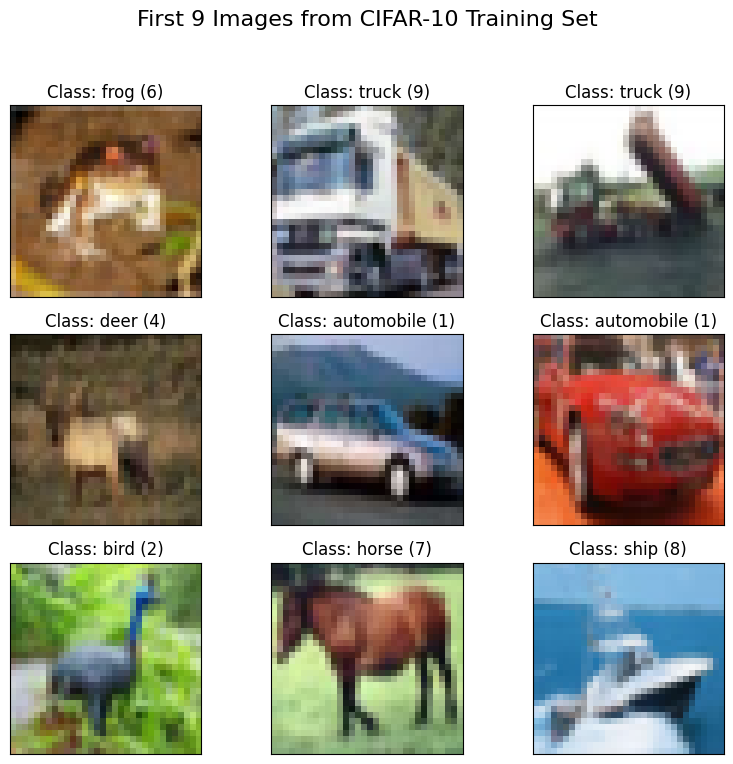

In [25]:
# Define the human-readable names for the CIFAR-10 classes (indices 0-9)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Set up the figure and axes for a 3x3 grid
plt.figure(figsize=(8, 8)) # Creates a figure window, size 8x8 inches
plt.suptitle("First 9 Images from CIFAR-10 Training Set", fontsize=16)

# Loop through the first 9 images (index 0 to 8)
for i in range(9):
    plt.subplot(3, 3, i + 1)

    # Display the i-th image
    plt.imshow(train_images[i])

    # Remove the ticks and labels from the x and y axes for cleaner visualization
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Get the actual label index for the image
    label_index = train_labels[i][0]
    # Get the corresponding class name from our list
    label_name = class_names[label_index]

    plt.title(f"Class: {label_name} ({label_index})")

# Adjust layout to prevent labels/titles overlapping
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

The images are quite small (32x32 pixels) and visibly pixelated. Details are often blurry or indistinct. Some objects are relatively clear (like some trucks or airplanes), while others (especially animals like cats, dogs, birds) can be difficult to identify even for a human, sometimes due to occlusion, viewpoint, or just the low resolution. There is also significant variation within each class.

In essence, the low resolution of CIFAR-10 makes it a good benchmark for learning and testing CNN architectures efficiently, but the models trained on it might not capture the level of detail needed for real-world, high-resolution image tasks without further adaptation or training on higher-resolution data.

In [26]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential

In [27]:
# 1. Preprocess Labels: One-Hot Encode
print("--- Preprocessing Labels ---")
print("Original train_labels shape:", train_labels.shape)
print("Original test_labels shape:", test_labels.shape)
print("Example original label:", train_labels[0])

--- Preprocessing Labels ---
Original train_labels shape: (50000, 1)
Original test_labels shape: (10000, 1)
Example original label: [6]


In [28]:
num_classes = 10 # We know CIFAR-10 has 10 classes
train_labels_one_hot = to_categorical(train_labels, num_classes)
test_labels_one_hot = to_categorical(test_labels, num_classes)

print("\nShape of one-hot encoded train_labels:", train_labels_one_hot.shape)
print("Shape of one-hot encoded test_labels:", test_labels_one_hot.shape)
print("Example one-hot encoded label (for original label", train_labels[0],"):\n", train_labels_one_hot[0])


Shape of one-hot encoded train_labels: (50000, 10)
Shape of one-hot encoded test_labels: (10000, 10)
Example one-hot encoded label (for original label [6] ):
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [29]:
# 2. Preprocess Images: Convert Type and Scale
print("\n--- Preprocessing Images ---")
print("Original train_images dtype:", train_images.dtype)
print("Original train_images min/max value:", train_images.min(), train_images.max())

# Convert pixel data type from uint8 to float32
# Neural networks typically perform calculations using floating-point numbers.
train_images_processed = train_images.astype('float32')
test_images_processed = test_images.astype('float32')

# Scale pixel values from the range [0, 255] to the range [0, 1]
# Normalizing input data helps the training process converge faster and more stably.
train_images_processed /= 255.0
test_images_processed /= 255.0

print("\nProcessed train_images dtype:", train_images_processed.dtype)
print("Processed train_images min/max value:", train_images_processed.min(), train_images_processed.max())
print("Processed train_images shape:", train_images_processed.shape) # Shape remains the same



--- Preprocessing Images ---
Original train_images dtype: uint8
Original train_images min/max value: 0 255

Processed train_images dtype: float32
Processed train_images min/max value: 0.0 1.0
Processed train_images shape: (50000, 32, 32, 3)


In [30]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import SGD

In [31]:
def define_model(input_shape, num_classes):

    model = Sequential(name="Baseline_CNN_CIFAR10")

    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))

    model.add(Dense(num_classes, activation='softmax'))

    optimizer = SGD(learning_rate=0.001, momentum=0.9)

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    print(f"Model '{model.name}' defined and compiled successfully.")

    return model

In [32]:
# Define input shape and number of classes (should be derived from data)
input_shape = train_images_processed.shape[1:] # e.g., (32, 32, 3)
num_classes = 10 # For CIFAR-10

# Create the model using the function
baseline_model = define_model(input_shape, num_classes)

# Print the model summary to see the layers, output shapes, and parameter counts
print("\n--- Model Summary ---")
baseline_model.summary()

Model 'Baseline_CNN_CIFAR10' defined and compiled successfully.

--- Model Summary ---


Model: "Baseline_CNN_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# --- Create the Compiled Model ---
input_shape = train_images_processed.shape[1:] # e.g., (32, 32, 3)
num_classes = 10 # For CIFAR-10

In [34]:
# Create the compiled model using the updated function
compiled_model = define_model(input_shape, num_classes)

Model 'Baseline_CNN_CIFAR10' defined and compiled successfully.


In [35]:
# Display model summary (optional, but good practice)
print("\n--- Model Summary ---")
compiled_model.summary()


--- Model Summary ---


Model: "Baseline_CNN_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Define training hyperparameters
epochs = 15
batch_size = 64

history = compiled_model.fit(train_images_processed, train_labels_one_hot,
                             epochs=epochs,
                             batch_size=batch_size,
                             validation_data=(test_images_processed, test_labels_one_hot),
                             verbose=1)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 270s 342ms/step - accuracy: 0.1582 - loss: 2.2278 - val_accuracy: 0.3201 - val_loss: 1.9403
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 315s 333ms/step - accuracy: 0.3600 - loss: 1.8110 - val_accuracy: 0.4090 - val_loss: 1.6493
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 260s 331ms/step - accuracy: 0.4403 - loss: 1.5825 - val_accuracy: 0.4461 - val_loss: 1.5569
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 255s 322ms/step - accuracy: 0.4859 - loss: 1.4476 - val_accuracy: 0.5189 - val_loss: 1.3538
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 270s 333ms/step - accuracy: 0.5237 - loss: 1.3458 - val_accuracy: 0.5393 - val_loss: 1.3020
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 266s 338ms/step - accuracy: 0.5526 - loss: 1.2611 - val_accuracy: 0.5450 - val_loss: 1.2698
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 310s 323ms/step - accuracy: 0.5779 - loss: 1.1985 - val_accuracy: 0.5772 - val_loss: 1.2007
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 251s 320ms/step - accuracy: 0.5999 -

In [18]:
# Evaluate the model on the test data
test_loss, test_accuracy = compiled_model.evaluate(test_images_processed,
                                                   test_labels_one_hot,
                                                   batch_size=64,
                                                   verbose=0)

# Print the results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# --- Discussion ---
print("\n--- Discussion on Accuracy ---")
if test_accuracy is not None:
    accuracy_percentage = test_accuracy * 100
    print(f"The achieved test accuracy is {accuracy_percentage:.2f}%.")

    if accuracy_percentage < 50.0:
        print("This accuracy is relatively low. It indicates the model is struggling significantly "
              "to generalize beyond the training data or hasn't learned effectively.")
    elif accuracy_percentage < 70.0:
        print("This accuracy shows the model has learned some patterns, but it's considerably lower "
              "than typical results for moderately tuned CNNs on CIFAR-10 (which often reach 75-85%+). "
              "It serves as a 'baseline', but there's significant room for improvement.")
    elif accuracy_percentage < 85.0:
        print("This is a reasonable accuracy for a simple baseline CNN on CIFAR-10 without significant "
              "tuning or advanced techniques like data augmentation or regularization (beyond basic structure). "
              "It demonstrates the effectiveness of CNNs, but state-of-the-art models achieve higher scores (90%+).")
    else:
        print("This accuracy is quite good, approaching or exceeding typical results for well-tuned standard CNNs "
              "on CIFAR-10. Further improvements might require more advanced architectures, regularization, "
              "or data augmentation techniques.")

    print("\nIs it satisfactory?")
    print("For a *baseline* model in a learning exercise, achieving an accuracy significantly better than random chance "
          "(which is 10% for 10 classes) and potentially reaching 60-75% range could be considered 'satisfactory' "
          "as a starting point. It demonstrates the fundamental concepts work.")
    print("However, in terms of solving the CIFAR-10 task competitively, accuracies below 80-85% are generally "
          "not considered state-of-the-art or highly satisfactory. The goal of a baseline is often to establish a "
          "starting point for future improvements (e.g., by adding more layers, dropout, batch normalization, data augmentation).")

else:
    print("Model evaluation did not complete successfully.")

Test Loss: 1.0309
Test Accuracy: 64.37%

--- Discussion on Accuracy ---
The achieved test accuracy is 64.37%.
This accuracy shows the model has learned some patterns, but it's considerably lower than typical results for moderately tuned CNNs on CIFAR-10 (which often reach 75-85%+). It serves as a 'baseline', but there's significant room for improvement.

Is it satisfactory?
For a *baseline* model in a learning exercise, achieving an accuracy significantly better than random chance (which is 10% for 10 classes) and potentially reaching 60-75% range could be considered 'satisfactory' as a starting point. It demonstrates the fundamental concepts work.
However, in terms of solving the CIFAR-10 task competitively, accuracies below 80-85% are generally not considered state-of-the-art or highly satisfactory. The goal of a baseline is often to establish a starting point for future improvements (e.g., by adding more layers, dropout, batch normalization, data augmentation).



--- Plotting Training History ---


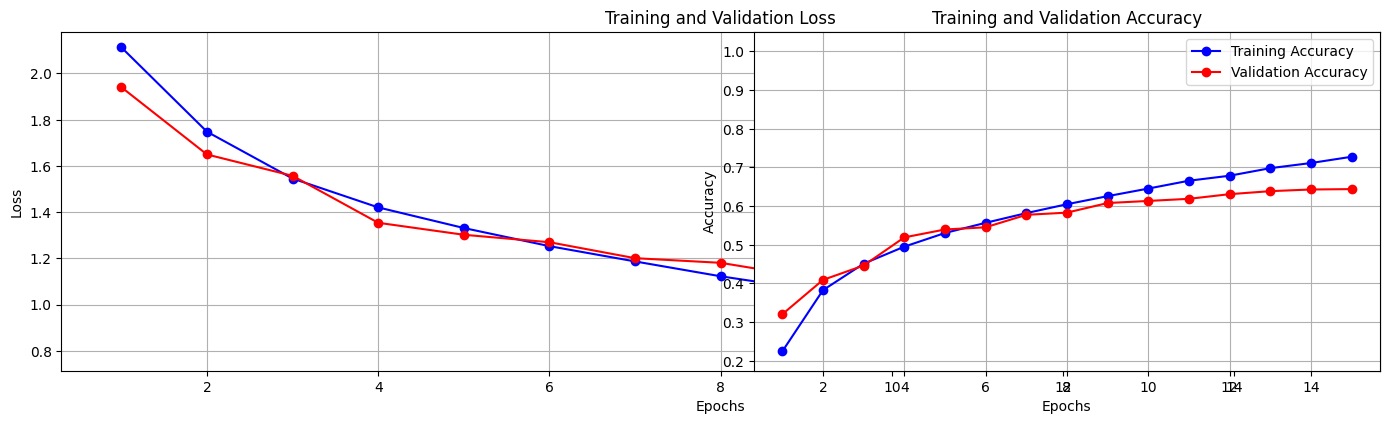

In [19]:
print("\n--- Plotting Training History ---")

# Check if the 'history' object exists from the previous training step
if 'history' in locals() or 'history' in globals():
    # Extract history data
    history_dict = history.history
    train_loss = history_dict['loss']
    val_loss = history_dict['val_loss']
    train_accuracy = history_dict['accuracy']
    val_accuracy = history_dict['val_accuracy']

    # Get the number of epochs the training actually ran for
    epochs_range = range(1, len(train_accuracy) + 1)


    plt.figure(figsize=(14, 5)) # Width, Height in inches

    plt.subplot
    plt.plot(epochs_range, train_loss, 'bo-', label='Training Loss') # Blue line with dots
    plt.plot(epochs_range, val_loss, 'ro-', label='Validation Loss') # Red line with dots
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_accuracy, 'bo-', label='Training Accuracy') # Blue line with dots
    plt.plot(epochs_range, val_accuracy, 'ro-', label='Validation Accuracy') # Red line with dots
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    min_acc = min(min(train_accuracy), min(val_accuracy))
    plt.ylim([max(0, min_acc - 0.05), 1.05])
    plt.legend()
    plt.grid(True)

    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()

**Conclusions from the Plots and Results:**

1.  **Convergence:** The model has learned. Both loss curves decreased significantly, and accuracy curves increased significantly from the start. The validation curves plateauing suggests that the model has reached the limit of its generalization capability with this architecture and data around epoch 8-10.
2.   **Overfitting:** There are clear signs of overfitting, starting around epoch 6-8. The model continues to improve its performance on the training data (lower training loss, higher training accuracy), but its performance on the unseen validation (test) data stops improving and remains stuck (or slightly worsens). The model is starting to memorize the training examples rather than learning generalizable patterns.
3. **Performance Limit:** The validation accuracy plateaus around 64-65%, which is consistent with the final evaluated test accuracy of 63.79%. This indicates that, for this specific simple CNN architecture and training setup (15 epochs, SGD optimizer), this is roughly the best performance achievable on unseen data before overfitting dominates.
4. **Satisfactory?** As discussed before, 63.79% is significantly better than random chance (10%) and shows the CNN is working. However, the overfitting suggests the model's capacity or the training process isn't optimal for generalization on this dataset. It serves as a good baseline, but highlights the need for techniques to improve generalization (like regularization, data augmentation, or architectural changes) if higher accuracy is desired. Stopping the training earlier (e.g., around epoch 10-12 where validation accuracy peaked) might have yielded slightly better test results (early stopping).




Model 'CNN_With_Dropout_CIFAR10' defined and compiled successfully.

--- Model Summary (with Dropout) ---


Model: "CNN_With_Dropout_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)


--- Starting Model Training (with Dropout) ---
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 255s 324ms/step - accuracy: 0.1568 - loss: 2.2302 - val_accuracy: 0.3286 - val_loss: 1.8810
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 263s 336ms/step - accuracy: 0.3271 - loss: 1.8795 - val_accuracy: 0.4142 - val_loss: 1.6281
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 320s 334ms/step - accuracy: 0.3991 - loss: 1.6516 - val_accuracy: 0.4555 - val_loss: 1.4926
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 251s 320ms/step - accuracy: 0.4529 - loss: 1.5083 - val_accuracy: 0.4855 - val_loss: 1.4297
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 264s 322ms/step - accuracy: 0.4887 - loss: 1.4218 - val_accuracy: 0.5164 - val_loss: 1.3671
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 252s 323ms/step - accuracy: 0.5156 - loss: 1.3599 - val_accuracy: 0.5584 - val_loss: 1.2409
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 268s 331ms/step - accuracy: 0.5369 - loss: 1.2906 - val_accuracy: 0.5738 - val_loss: 1.2149
Epoch 8/15
782/782 ━━━━━━━━━

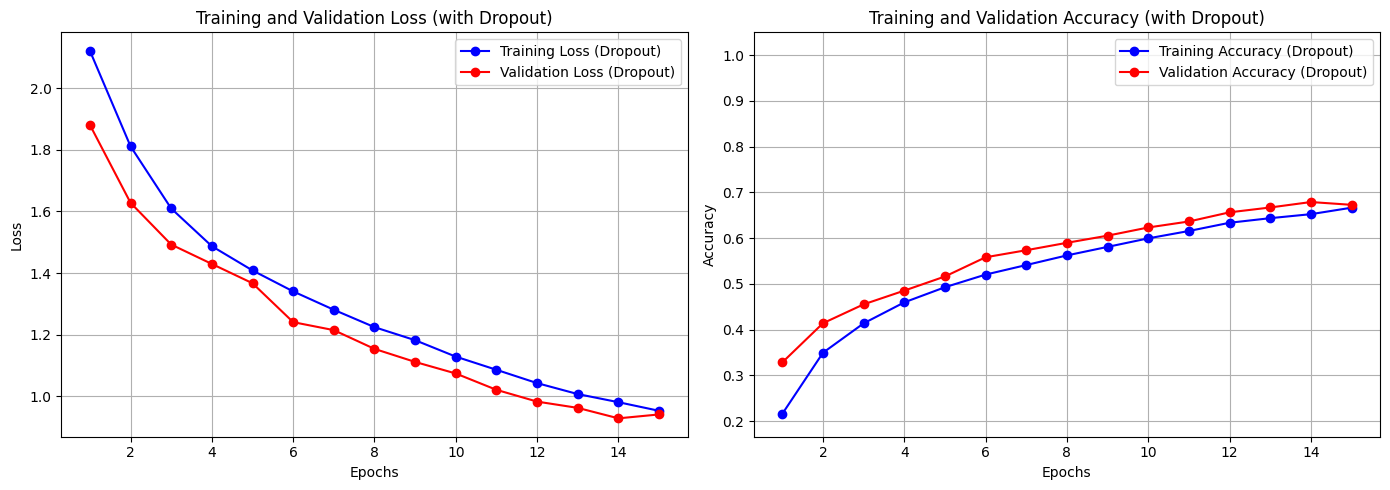

In [38]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def define_compile_model_with_dropout(input_shape, num_classes):

    model = Sequential(name="CNN_With_Dropout_CIFAR10")

    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())
    model.add(Dropout(0.5))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    optimizer = SGD(learning_rate=0.001, momentum=0.9)

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    print(f"Model '{model.name}' defined and compiled successfully.")
    return model

input_shape = train_images_processed.shape[1:]
num_classes = 10
dropout_model = define_compile_model_with_dropout(input_shape, num_classes)

print("\n--- Model Summary (with Dropout) ---")
dropout_model.summary()

print("\n--- Starting Model Training (with Dropout) ---")

epochs = 15
batch_size = 64

history_dropout = dropout_model.fit(train_images_processed, train_labels_one_hot,
                                    epochs=epochs,
                                    batch_size=batch_size,
                                    validation_data=(test_images_processed, test_labels_one_hot),
                                    verbose=1)
print("\n--- Model Training Finished (with Dropout) ---")

print("\n--- Evaluating Model Performance on Test Set (with Dropout) ---")

test_loss_dropout, test_accuracy_dropout = dropout_model.evaluate(test_images_processed,
                                                                  test_labels_one_hot,
                                                                  batch_size=batch_size,
                                                                  verbose=0)

print(f"Test Loss (Dropout): {test_loss_dropout:.4f}")
print(f"Test Accuracy (Dropout): {test_accuracy_dropout * 100:.2f}%")

print("\n--- Plotting Training History (with Dropout) ---")

history_dict_dropout = history_dropout.history
train_loss_dropout = history_dict_dropout['loss']
val_loss_dropout = history_dict_dropout['val_loss']
train_accuracy_dropout = history_dict_dropout['accuracy']
val_accuracy_dropout = history_dict_dropout['val_accuracy']

epochs_range = range(1, len(train_accuracy_dropout) + 1)

plt.figure(figsize=(14, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_dropout, 'bo-', label='Training Loss (Dropout)')
plt.plot(epochs_range, val_loss_dropout, 'ro-', label='Validation Loss (Dropout)')
plt.title('Training and Validation Loss (with Dropout)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracy_dropout, 'bo-', label='Training Accuracy (Dropout)')
plt.plot(epochs_range, val_accuracy_dropout, 'ro-', label='Validation Accuracy (Dropout)')
plt.title('Training and Validation Accuracy (with Dropout)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
min_acc_dropout = min(min(train_accuracy_dropout), min(val_accuracy_dropout))
plt.ylim([max(0, min_acc_dropout - 0.05), 1.05])
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Model 'Final_CNN_CIFAR10' defined and compiled successfully.

--- Final Model Summary ---


Model: "Final_CNN_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)


--- Starting Final Model Training ---
Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 370s 471ms/step - accuracy: 0.1217 - loss: 2.2868 - val_accuracy: 0.2685 - val_loss: 2.0217
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 381s 470ms/step - accuracy: 0.2620 - loss: 2.0004 - val_accuracy: 0.3582 - val_loss: 1.8353
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 381s 469ms/step - accuracy: 0.3381 - loss: 1.8231 - val_accuracy: 0.4161 - val_loss: 1.6153
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 383s 470ms/step - accuracy: 0.3900 - loss: 1.6684 - val_accuracy: 0.4486 - val_loss: 1.5232
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 365s 467ms/step - accuracy: 0.4287 - loss: 1.5644 - val_accuracy: 0.4800 - val_loss: 1.4150
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 379s 463ms/step - accuracy: 0.4557 - loss: 1.4955 - val_accuracy: 0.5032 - val_loss: 1.3669
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 387s 469ms/step - accuracy: 0.4982 - loss: 1.3971 - val_accuracy: 0.5339 - val_loss: 1.2888
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━

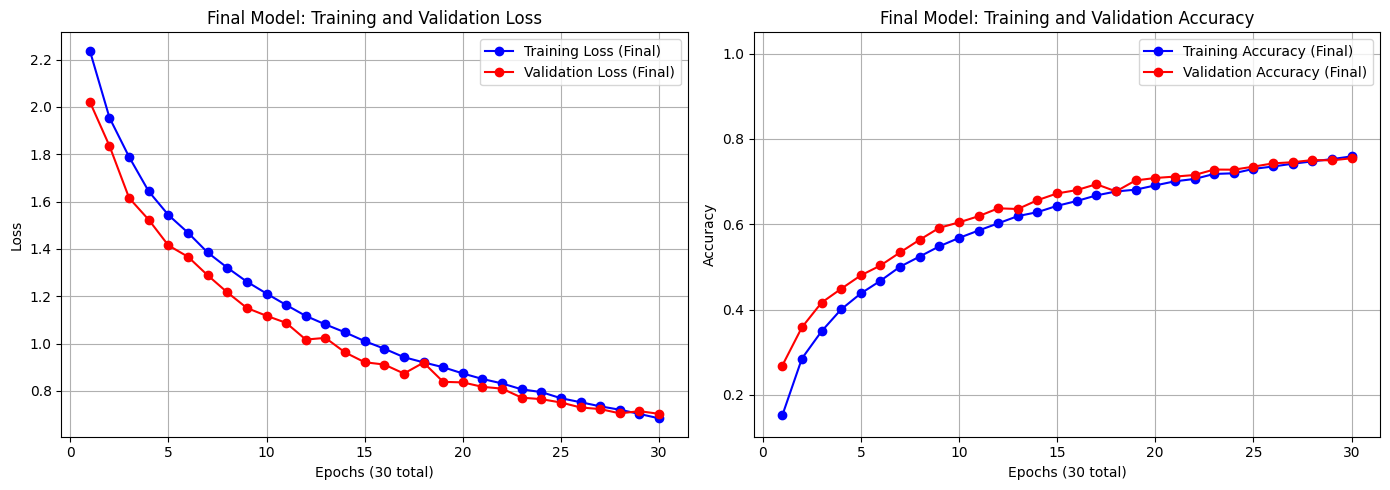

In [41]:
def define_compile_final_model(input_shape, num_classes):

    model = Sequential(name="Final_CNN_CIFAR10")

    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2))

    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2))

    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(num_classes, activation='softmax'))

    optimizer = SGD(learning_rate=0.001, momentum=0.9)

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    print(f"Model '{model.name}' defined and compiled successfully.")
    return model

input_shape = train_images_processed.shape[1:]
num_classes = 10

final_model = define_compile_final_model(input_shape, num_classes)

print("\n--- Final Model Summary ---")
final_model.summary()

print("\n--- Starting Final Model Training ---")

epochs = 30 # Train for 30 epochs as requested
batch_size = 64 # Keep batch size the same

history_final = final_model.fit(train_images_processed, train_labels_one_hot,
                                epochs=epochs,
                                batch_size=batch_size,
                                validation_data=(test_images_processed, test_labels_one_hot),
                                verbose=1) # Show progress

print("\n--- Final Model Training Finished ---")

print("\n--- Evaluating Final Model Performance on Test Set ---")

test_loss_final, test_accuracy_final = final_model.evaluate(test_images_processed,
                                                          test_labels_one_hot,
                                                          batch_size=batch_size,
                                                          verbose=0)

print(f"Final Model Test Loss: {test_loss_final:.4f}")
print(f"Final Model Test Accuracy: {test_accuracy_final * 100:.2f}%")

print("\n--- Plotting Training History (Final Model) ---")

history_dict_final = history_final.history
train_loss_final = history_dict_final['loss']
val_loss_final = history_dict_final['val_loss']
train_accuracy_final = history_dict_final['accuracy']
val_accuracy_final = history_dict_final['val_accuracy']

epochs_range_final = range(1, len(train_accuracy_final) + 1)

plt.figure(figsize=(14, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range_final, train_loss_final, 'bo-', label='Training Loss (Final)')
plt.plot(epochs_range_final, val_loss_final, 'ro-', label='Validation Loss (Final)')
plt.title('Final Model: Training and Validation Loss')
plt.xlabel(f'Epochs ({epochs} total)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range_final, train_accuracy_final, 'bo-', label='Training Accuracy (Final)')
plt.plot(epochs_range_final, val_accuracy_final, 'ro-', label='Validation Accuracy (Final)')
plt.title('Final Model: Training and Validation Accuracy')
plt.xlabel(f'Epochs ({epochs} total)')
plt.ylabel('Accuracy')
min_acc_final = min(min(train_accuracy_final), min(val_accuracy_final))
plt.ylim([max(0, min_acc_final - 0.05), 1.05])
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()